In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset_path = "adult.csv"
df = pd.read_csv(dataset_path)

In [ ]:
df.sample(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
11569,61,State-gov,205482,HS-grad,9,Married-spouse-absent,Transport-moving,Not-in-family,White,Female,0,0,60,United-States,<=50K
21670,42,Self-emp-not-inc,207392,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,12,United-States,<=50K
4052,24,Private,81145,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,25,United-States,<=50K
28502,33,Federal-gov,88913,Some-college,10,Never-married,Adm-clerical,Own-child,Asian-Pac-Islander,Female,0,0,40,United-States,<=50K
33441,38,Private,247111,HS-grad,9,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K


In [ ]:
df.shape

(48842, 15)

In [ ]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

The missing values in the dataset is marked as '?' instead of Null

In [ ]:
df[df != '?'].isnull().sum()/df.shape[0]*100

age                0.000000
workclass          5.730724
fnlwgt             0.000000
education          0.000000
educational-num    0.000000
marital-status     0.000000
occupation         5.751198
relationship       0.000000
race               0.000000
gender             0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     0.000000
native-country     1.754637
income             0.000000
dtype: float64

Here we can observe that workclass, occupation, and native-country have missing values. workclass and occupation have around 5.7% missing values while native-country only have 1.7% missing values.

In [ ]:
print(f"Most frequent in workclass = {df['workclass'].mode()[0]}")
df['workclass'] = df['workclass'].replace('?', df['workclass'].mode()[0])

print(f"Most frequent in workclass = {df['occupation'].mode()[0]}")
df['occupation'] = df['occupation'].replace('?', df['occupation'].mode()[0])

print(f"Most frequent in workclass = {df['native-country'].mode()[0]}")
df['native-country'] = df['native-country'].replace('?', df['native-country'].mode()[0])

print("Replaced each '?' with the most frequent value in that column")

Most frequent in workclass = Private
Most frequent in workclass = Prof-specialty
Most frequent in workclass = United-States
Replaced each '?' with the most frequent value in that column


In [ ]:
df[df != '?'].isnull().sum()/df.shape[0]*100

age                0.0
workclass          0.0
fnlwgt             0.0
education          0.0
educational-num    0.0
marital-status     0.0
occupation         0.0
relationship       0.0
race               0.0
gender             0.0
capital-gain       0.0
capital-loss       0.0
hours-per-week     0.0
native-country     0.0
income             0.0
dtype: float64

replace '?' with the most frequent elemnt in that column

In [ ]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
# Unweighted
unweighted_gender = (
    df.groupby(['gender', 'income'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

# Weighted
weighted_gender = (
    df.groupby(['gender', 'income'])['fnlwgt']
    .sum()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

# Combine
gender_comparison = pd.concat(
    [unweighted_gender, weighted_gender], axis=1
)
gender_comparison.columns = ['unweighted', 'weighted']

gender_comparison

unweighted  weighted
gender gender income                      
Female Female <=50K     0.890749  0.891641
              >50K      0.109251  0.108359
Male   Male   <=50K     0.696233  0.700126
              >50K      0.303767  0.299874

This show that the sample good enough representation of the overall population and we can afford to ignore fngwgt column during analysis

<Axes: xlabel='income', ylabel='fnlwgt'>

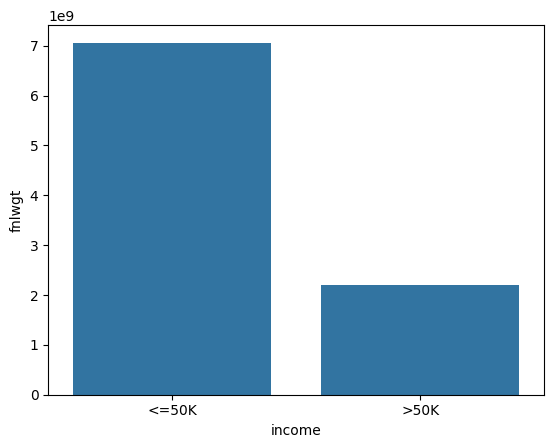

In [ ]:
weighted_counts = df.groupby('income')['fnlwgt'].sum().reset_index()

sns.barplot(x='income', y='fnlwgt', data=weighted_counts)

Number of people earning <50k are more as compared to people earning >50k 

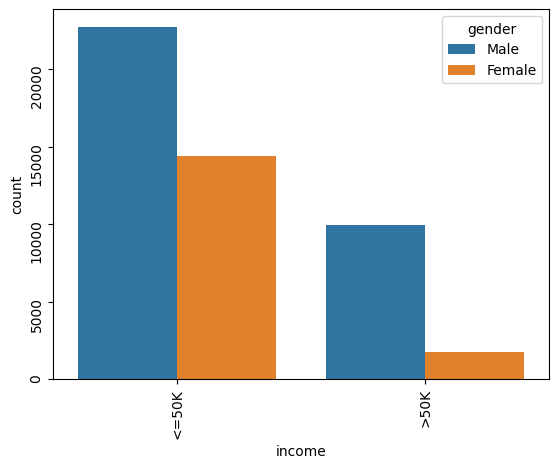

In [ ]:
sns.countplot(df, x='income', hue='gender')
plt.tick_params(rotation=90)

In both income categories, number of males are more than females specially in >50k group.

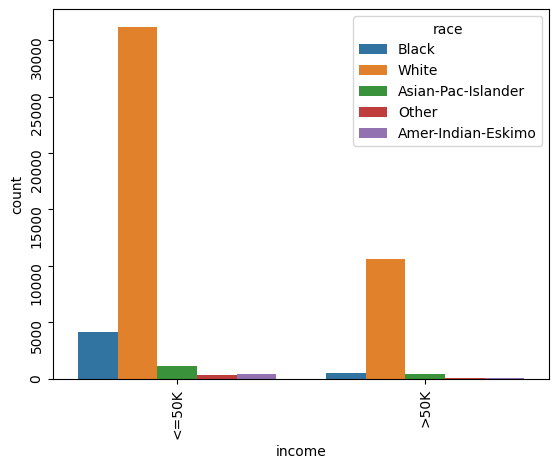

In [ ]:
sns.countplot(df, x='income', hue='race')
plt.tick_params(rotation=90)

People of 'White' race dominate both income groups.

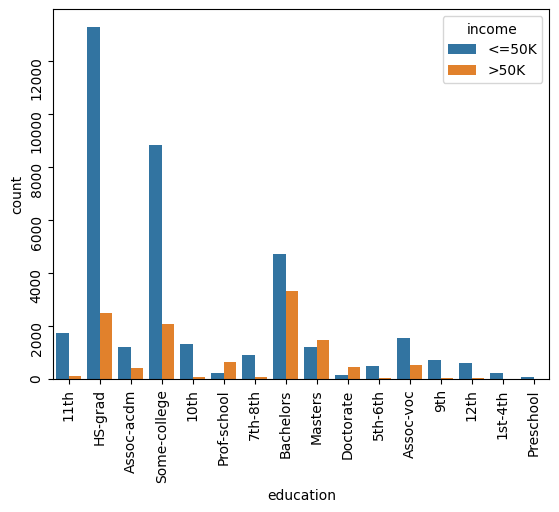

In [ ]:
sns.countplot(df, x='education', hue='income')
plt.tick_params(rotation=90)

This shows that with higher education people are more likely to get higher salaries specially in Masters and Doctrate and get in >50k income group

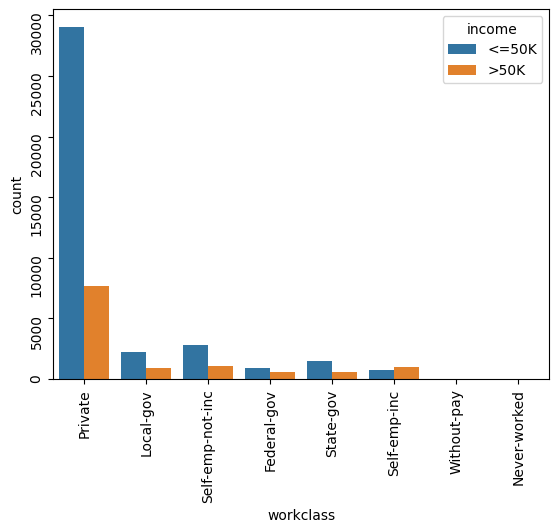

In [ ]:
sns.countplot(df, x='workclass', hue='income')
plt.tick_params(rotation=90)

1. This shows that most of the people are doing private jobs
2. People who are self employed are more likely to be in >50k income group

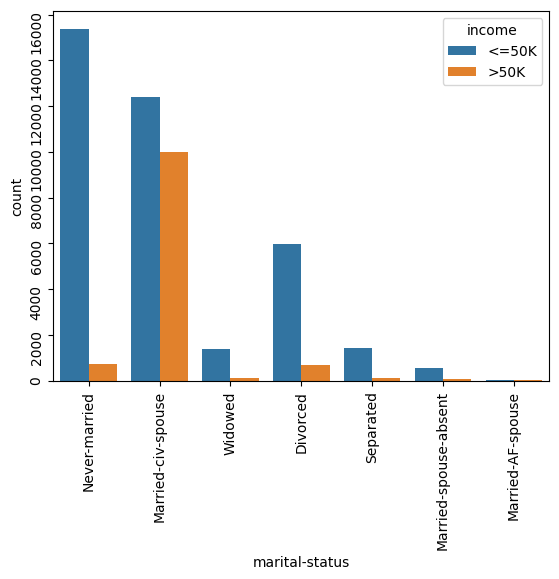

In [ ]:
sns.countplot(df, x='marital-status', hue='income')
plt.tick_params(rotation=90)

This shows that people in >50k income group are more likely to be married

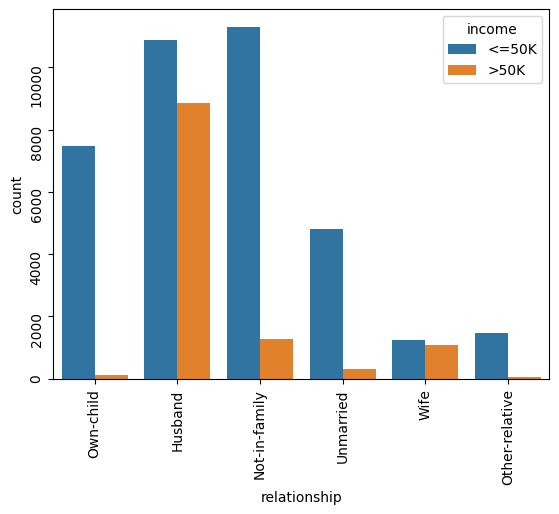

In [ ]:
sns.countplot(df, x='relationship', hue='income')
plt.tick_params(rotation=90)

1. Husbands and wife have almost similar number of people in both income group
2. people who own a child or are unmarried are mostly in <50k income group

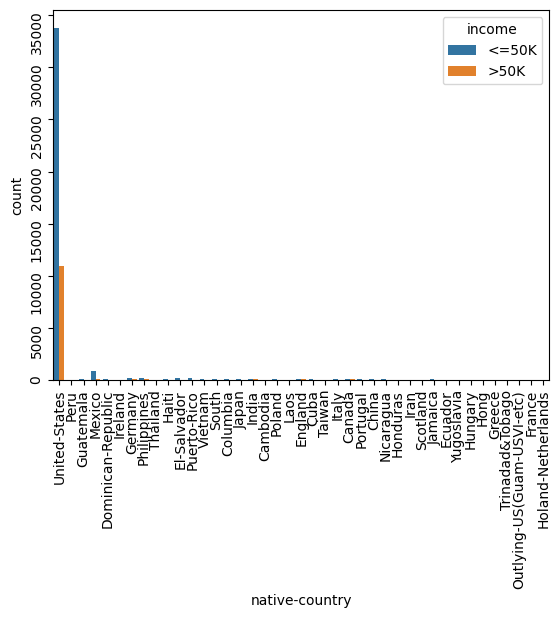

In [ ]:
sns.countplot(df, x='native-country', hue='income')
plt.tick_params(rotation=90)

This data is mostly consists of people from United States

<Axes: xlabel='age', ylabel='Density'>

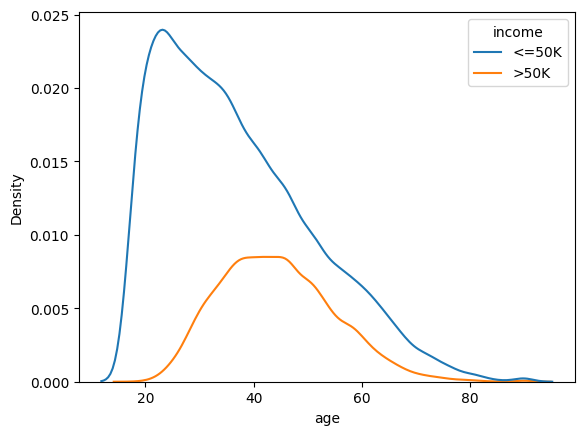

In [ ]:
sns.kdeplot(data = df, x = 'age', hue = 'income')

1. For people earning <50K the income plot is highly right skewed indicating presence of outliers who despite being older are still earning in same pay range.

2. Its centered around age 20-30 which means most of the people are young or at start of their careers probably<br>

3. For people earning >50k the graph is more normally distributed(though still slightly right skewed).

4. The plot is centered around 40-50 indicating that people of this pay range of expected to be middle age and later stage of their careers mostly(though not necessary)

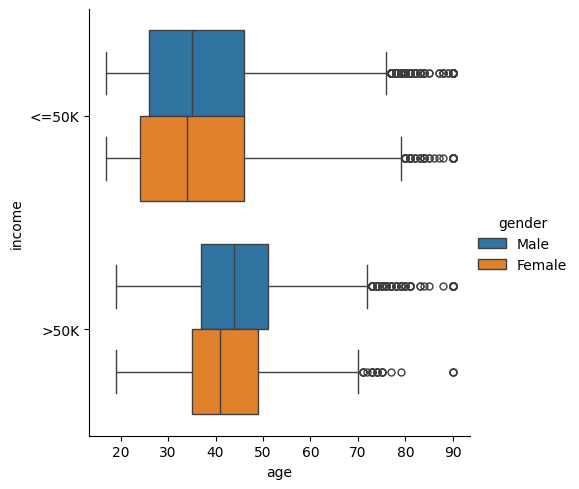

In [ ]:
sns.catplot(data=df, x="age", y="income",hue = 'gender', kind="box")

1. In both income group median age of female is less than male.
2. In <50k income group female age range is wider than male showing that there are many old womens still earning in this pay range.

<Axes: xlabel='hours-per-week', ylabel='Density'>

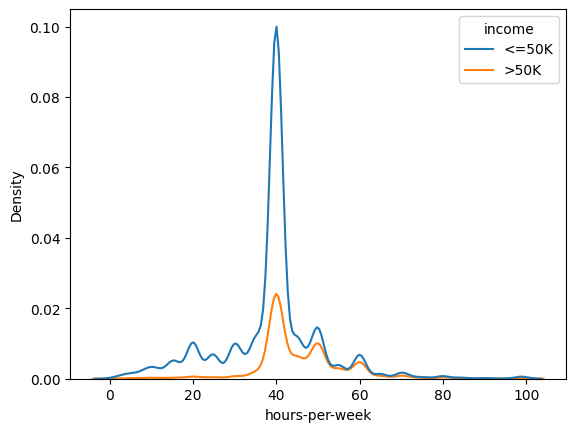

In [ ]:
sns.kdeplot(data = df, x = 'hours-per-week', hue = 'income')

1. This shows that both income groups mostly work for 40 or 60 hours per week
2. One interesting obesrvation is that there are some people in <50k income group which work less than 40 hours per week while such cases are negligable in the >50k income group indicating that they work atleast for 40 hours per week or more

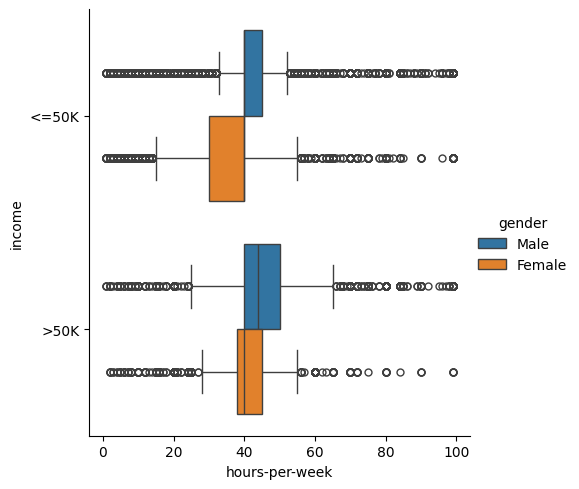

In [ ]:
sns.catplot(data=df, x="hours-per-week", y="income",hue = 'gender', kind="box")

This plot clearly shows that in both income groups female have less hours-per-week as compared to male(though there are many outliers)

<Axes: xlabel='educational-num', ylabel='Density'>

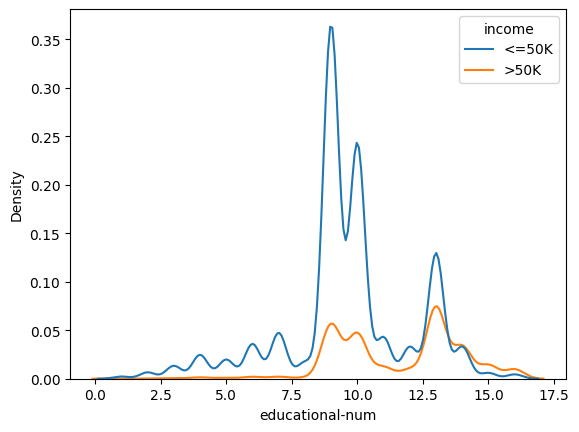

In [ ]:
sns.kdeplot(data = df, x = 'educational-num', hue = 'income')

This shows that people in >50k income group have high educational number, while in the <50k income group there are still people with lower educational number as compared to the expected(which is around 8-11)

<Axes: xlabel='capital-gain', ylabel='Density'>

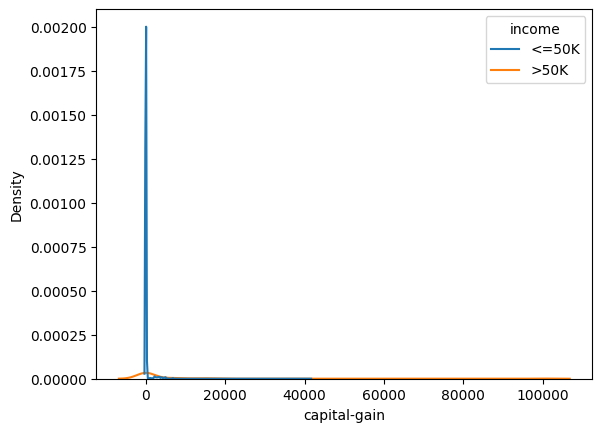

In [ ]:
sns.kdeplot(data = df, x = 'capital-gain', hue = 'income')

This shows that there are some outliers people who gained capital though people in >50k income group have more extreme outlier which is expected

<Axes: xlabel='capital-loss', ylabel='Density'>

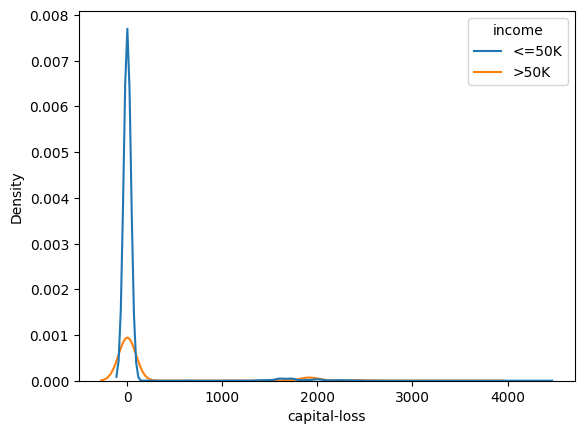

In [ ]:
sns.kdeplot(data = df, x = 'capital-loss', hue = 'income')

This shows that there are some outliers in both groups who faced heavy capital loss though people in <50k income group have more extreme cases present

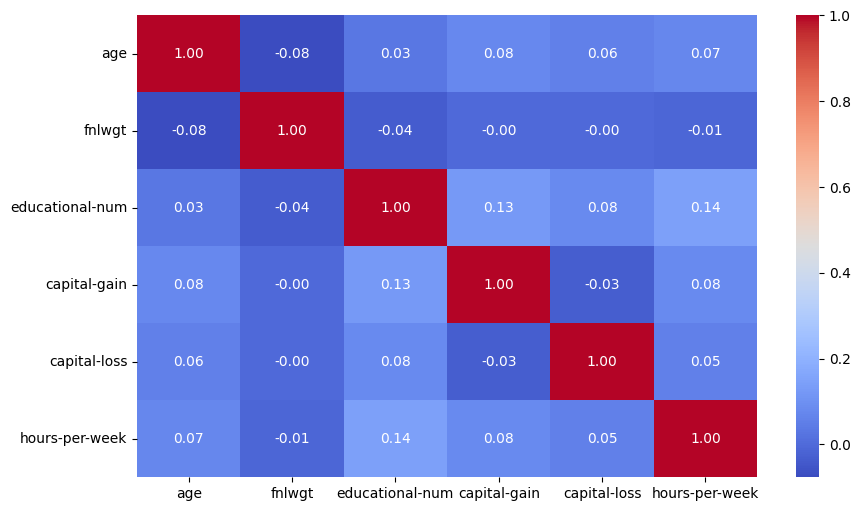

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Most of the numerical columns are not correlated